In [1]:
# tumor_identification_metrics.ipynb - plot metrics (F1 score etc) of tumor identification.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from matplotlib.patches import Patch

In [3]:
root_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1r1n1t/vary_tumor_prop'
out_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1r1n1t/vary_tumor_prop/analysis/tumor_identification/calicost'
with_ref = 'calicost'

## Merge metrics from multiple experiments into one single file.

In [4]:
run_id_list = sorted([d for d in os.listdir(root_dir) if d.endswith('t')])
run_id_list

['100n900t',
 '10n990t',
 '300n700t',
 '30n970t',
 '500n500t',
 '700n300t',
 '900n100t',
 '970n30t',
 '990n10t',
 '997n3t']

In [5]:
dat = None
for run_id in run_id_list:
    print("processing '%s' ..." % run_id)
    run_dir = os.path.join(root_dir, run_id)
    metric_fn = os.path.join(run_dir, 'tumor_identification/%s/2_metric/metrics.tsv' % \
                            (with_ref, ))
    if not os.path.exists(metric_fn):
        print("[W] file '%s' does not exist!" % metric_fn)
        continue
    df = pd.read_csv(metric_fn, sep = '\t')
    df['run_id'] = run_id
    if dat is None:
        dat = df
    else:
        dat = pd.concat([dat, df], ignore_index = True)
    print("dat shape: %s" % str(dat.shape))
dat

processing '100n900t' ...
dat shape: (15, 4)
processing '10n990t' ...
dat shape: (25, 4)
processing '300n700t' ...
dat shape: (40, 4)
processing '30n970t' ...
dat shape: (50, 4)
processing '500n500t' ...
dat shape: (65, 4)
processing '700n300t' ...
dat shape: (80, 4)
processing '900n100t' ...
dat shape: (85, 4)
processing '970n30t' ...
dat shape: (90, 4)
processing '990n10t' ...
dat shape: (95, 4)
processing '997n3t' ...
dat shape: (100, 4)


,tool,metric,value,run_id
0,CalicoST_ref_purity,accuracy,0.997949,100n900t
1,CalicoST_noref_purity,accuracy,0.990769,100n900t
2,CalicoST_noref_nopurity,accuracy,0.974359,100n900t
3,CalicoST_ref_purity,precision,0.997722,100n900t
4,CalicoST_noref_purity,precision,0.998849,100n900t
...,...,...,...,...
95,CalicoST_noref_nopurity,accuracy,0.997000,997n3t
96,CalicoST_noref_nopurity,precision,0.000000,997n3t
97,CalicoST_noref_nopurity,recall,0.000000,997n3t
98,CalicoST_noref_nopurity,F1,0.000000,997n3t


In [6]:
dat['tool'] = dat['tool'].str.removeprefix('CalicoST_')
dat.head()

,tool,metric,value,run_id
0,ref_purity,accuracy,0.997949,100n900t
1,noref_purity,accuracy,0.990769,100n900t
2,noref_nopurity,accuracy,0.974359,100n900t
3,ref_purity,precision,0.997722,100n900t
4,noref_purity,precision,0.998849,100n900t


In [7]:
metric_fn = os.path.join(out_dir, 'tumor_identification.%s.metrics.tsv' % with_ref)
dat.to_csv(
    metric_fn,
    sep = '\t',
    index = False
)

In [8]:
dat

,tool,metric,value,run_id
0,ref_purity,accuracy,0.997949,100n900t
1,noref_purity,accuracy,0.990769,100n900t
2,noref_nopurity,accuracy,0.974359,100n900t
3,ref_purity,precision,0.997722,100n900t
4,noref_purity,precision,0.998849,100n900t
...,...,...,...,...
95,noref_nopurity,accuracy,0.997000,997n3t
96,noref_nopurity,precision,0.000000,997n3t
97,noref_nopurity,recall,0.000000,997n3t
98,noref_nopurity,F1,0.000000,997n3t


## Plot

In [9]:
dat = pd.read_csv(
    metric_fn,
    sep = '\t'
)
dat

,tool,metric,value,run_id
0,ref_purity,accuracy,0.997949,100n900t
1,noref_purity,accuracy,0.990769,100n900t
2,noref_nopurity,accuracy,0.974359,100n900t
3,ref_purity,precision,0.997722,100n900t
4,noref_purity,precision,0.998849,100n900t
...,...,...,...,...
95,noref_nopurity,accuracy,0.997000,997n3t
96,noref_nopurity,precision,0.000000,997n3t
97,noref_nopurity,recall,0.000000,997n3t
98,noref_nopurity,F1,0.000000,997n3t


In [10]:
dat['run_id_raw'] = dat['run_id']
dat_raw = dat.copy()
dat = dat.loc[dat['run_id_raw'] != '997n3t'].copy()
dat['run_id'] = dat['run_id'].map({
    '10n990t':'99',
    '30n970t':'97',
    '100n900t':'90',
    '300n700t':'70',
    '500n500t':'50',
    '700n300t':'30',
    '900n100t':'10',
    '970n30t':'3',
    '990n10t':'1'
})
dat['run_id'] = pd.Categorical(
    dat['run_id'], 
    categories = [str(i) for i in (99, 97, 90, 70, 50, 30, 10, 3, 1)],
    ordered = True
)
dat

,tool,metric,value,run_id,run_id_raw
0,ref_purity,accuracy,0.997949,90,100n900t
1,noref_purity,accuracy,0.990769,90,100n900t
2,noref_nopurity,accuracy,0.974359,90,100n900t
3,ref_purity,precision,0.997722,90,100n900t
4,noref_purity,precision,0.998849,90,100n900t
...,...,...,...,...,...
90,noref_nopurity,accuracy,0.990000,1,990n10t
91,noref_nopurity,precision,0.000000,1,990n10t
92,noref_nopurity,recall,0.000000,1,990n10t
93,noref_nopurity,F1,0.000000,1,990n10t


In [11]:
dat['tool'] = dat['tool'].map({
    'ref_purity': 'ref(+)/purity(+)',
    'noref_purity': 'ref(-)/purity(+)',
    'noref_nopurity': 'ref(-)/purity(-)'
})
dat['tool'] = pd.Categorical(
    dat['tool'], 
    categories = ['ref(-)/purity(-)', 'ref(-)/purity(+)', 'ref(+)/purity(+)'],
    ordered = True
)
dat.head()

,tool,metric,value,run_id,run_id_raw
0,ref(+)/purity(+),accuracy,0.997949,90,100n900t
1,ref(-)/purity(+),accuracy,0.990769,90,100n900t
2,ref(-)/purity(-),accuracy,0.974359,90,100n900t
3,ref(+)/purity(+),precision,0.997722,90,100n900t
4,ref(-)/purity(+),precision,0.998849,90,100n900t


In [12]:
dat = dat[['tool', 'metric', 'run_id', 'value']].pivot(
    index = ['run_id', 'tool'],
    columns = 'metric',
    values = 'value'
).reset_index()
dat

metric,run_id,tool,ARI,F1,accuracy,precision,recall
0,99,ref(-)/purity(-),0.000000,0.000000,0.010000,0.000000,0.000000
1,99,ref(+)/purity(+),0.950904,0.999495,0.999000,1.000000,0.998990
2,97,ref(-)/purity(-),0.000000,0.000000,0.030030,0.000000,0.000000
3,97,ref(+)/purity(+),0.962439,0.998969,0.997998,0.997940,1.000000
4,90,ref(-)/purity(-),0.845480,0.985524,0.974359,1.000000,0.971461
5,90,ref(-)/purity(+),0.940120,0.994842,0.990769,0.998849,0.990868
6,90,ref(+)/purity(+),0.986177,0.998860,0.997949,0.997722,1.000000
7,70,ref(-)/purity(-),0.912015,0.984012,0.977978,1.000000,0.968526
8,70,ref(-)/purity(+),0.987699,0.997856,0.996997,0.997143,0.998569
9,70,ref(+)/purity(+),0.987693,0.997859,0.996997,0.995726,1.000000


In [13]:
def plot_metrics(df, metric, metric_label, figsize = (9, 5), fontsize = 10, total_bar_width = 0.7, ymin = 0):
    """Plot a grouped stacked bar chart of metric values.
    
    Parameters:
    ----------
    df : pd.DataFrame
        Must contain columns: 'tool', 'F1', 'run_id'.
    figsize : tuple, optional
        Figure size (width, height). Default is (9, 5).
    
    Returns:
    -------
    fig, ax : matplotlib figure and axes
    """
    required_cols = {'tool', metric, 'run_id'}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"DataFrame must contain columns: {required_cols}")
    
    # Ensure consistent ordering
    df = df.copy()
    df = df.sort_values(['run_id', 'tool']).reset_index(drop = True)

    # Pivot to get metric value per (run_id, tool, cna_type)
    pivot = df.pivot_table(
        index = 'run_id',
        columns = 'tool',
        values = metric,
        fill_value = -2
    )

    # Extract unique groups
    tool_order = ['ref(-)/purity(-)', 'ref(-)/purity(+)', 'ref(+)/purity(+)']
    run_ids = pivot.index.get_level_values('run_id').unique()
    tools = tool_order
    n_runs, n_tools = len(run_ids), len(tools)

    # Bar layout
    bar_width = total_bar_width / n_tools
    x_centers = np.arange(n_runs)

    # Colors
    tool_colors = ['#E69F00', '#56B4E9', '#F0E442']


    # Create plot
    fig, ax = plt.subplots(figsize = figsize)

    # Draw stacked bars
    y_star = 0.035
    for i, tool in enumerate(tools):
        for j, run in enumerate(run_ids):
            has_output = True
            if run in pivot.index:
                h = pivot.loc[run, tool]
                if h < -1:
                    has_output = False
            else:
                has_output = False
            x_pos = x_centers[j] + i * bar_width
            if has_output:
                ax.bar(
                    x_pos,
                    h,
                    bottom = 0,
                    width = bar_width,
                    color = tool_colors[i],
                    edgecolor = None,
                    linewidth = 0.5,
                    label = tool
                )
            else:
                ax.text(
                    x_pos, y_star,
                    '*', 
                    ha = 'center', va = 'top',
                    fontsize = fontsize - 2,
                    color = 'black',
                    weight = 'bold'
                )

    # Main axis styling
    ax.set_xticks(x_centers + bar_width * (n_tools - 1) / 2)
    ax.set_xticklabels(run_ids)
    ax.set_xlabel('Tumor percentage (%)', size = fontsize + 1)
    ax.set_ylabel(metric_label, fontsize = fontsize + 1)
    ax.set_xlim(0 - bar_width, n_runs - 1 + bar_width * n_tools)
    ax.set_ylim(ymin, 1.05)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Title (lowered to avoid top panel)
    #fig.suptitle('AUROC by Run, Tool, and CNA Type', y=0.95)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    #legend = fig.legend(
    #    [by_label[t] for t in tool_order], 
    #    tool_order, 
    #    title = None, 
    #    loc = 'upper center',
    #    frameon = False,
    #    ncol = 3,
    #    fontsize = fontsize,
    #    title_fontsize = fontsize,
    #    alignment = 'left',
    #    bbox_to_anchor = (0.53, 0.05)
    #)
    legend = fig.legend(
        [by_label[t] for t in tool_order], 
        tool_order, 
        title = 'CalicoST Setting', 
        loc = 'upper left',
        frameon = False,
        fontsize = fontsize - 1,
        title_fontsize = fontsize - 1,
        alignment = 'left',
        bbox_to_anchor = (0.97, 0.75)
    )

    plt.tight_layout()
    return fig, ax

### Plot F1

In [14]:
metric = 'F1'
metric_label = 'F1 score'
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,F1,run_id
0,ref(-)/purity(-),0.000000,99
1,ref(+)/purity(+),0.999495,99
2,ref(-)/purity(-),0.000000,97
3,ref(+)/purity(+),0.998969,97
4,ref(-)/purity(-),0.985524,90


/tmp/pbs.1790203.xomics/ipykernel_54619/1775419453.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


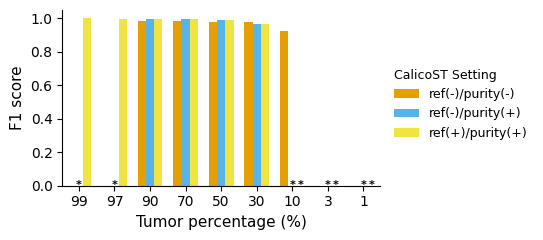

In [15]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (4, 2.5), fontsize = 10)

In [16]:
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

/tmp/pbs.1790203.xomics/ipykernel_54619/1775419453.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


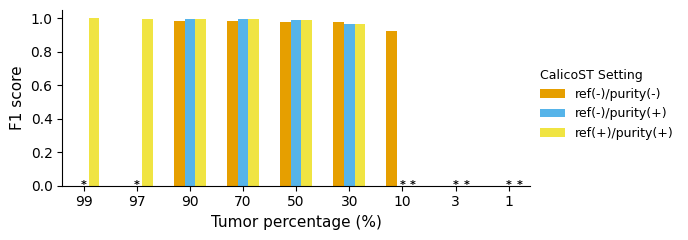

In [17]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (5.5, 2.5), fontsize = 10, total_bar_width = 0.6)
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.wide_version.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

### Plot accuracy

In [18]:
metric = 'accuracy'
metric_label = 'Accuracy'
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,accuracy,run_id
0,ref(-)/purity(-),0.010000,99
1,ref(+)/purity(+),0.999000,99
2,ref(-)/purity(-),0.030030,97
3,ref(+)/purity(+),0.997998,97
4,ref(-)/purity(-),0.974359,90


/tmp/pbs.1790203.xomics/ipykernel_54619/1775419453.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


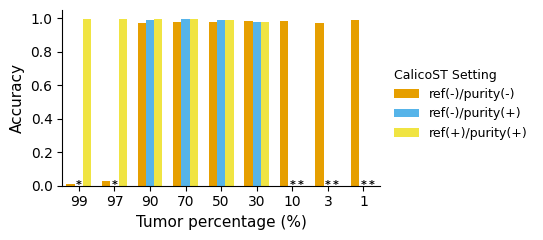

In [19]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (4, 2.5), fontsize = 10)

In [20]:
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

/tmp/pbs.1790203.xomics/ipykernel_54619/1775419453.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


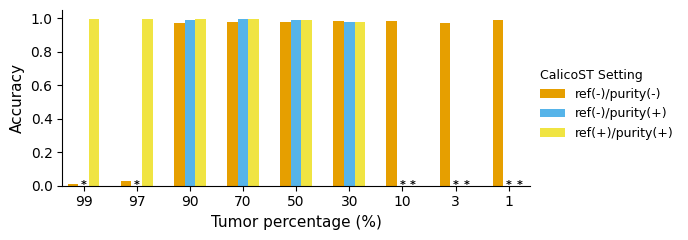

In [21]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (5.5, 2.5), fontsize = 10, total_bar_width = 0.6)
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.wide_version.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

### Plot precision

In [22]:
metric = 'precision'
metric_label = 'Precision'
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,precision,run_id
0,ref(-)/purity(-),0.00000,99
1,ref(+)/purity(+),1.00000,99
2,ref(-)/purity(-),0.00000,97
3,ref(+)/purity(+),0.99794,97
4,ref(-)/purity(-),1.00000,90


/tmp/pbs.1790203.xomics/ipykernel_54619/1775419453.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


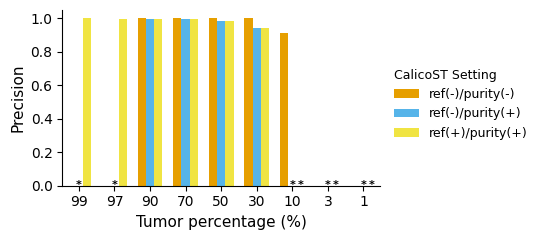

In [23]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (4, 2.5), fontsize = 10)
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

/tmp/pbs.1790203.xomics/ipykernel_54619/1775419453.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


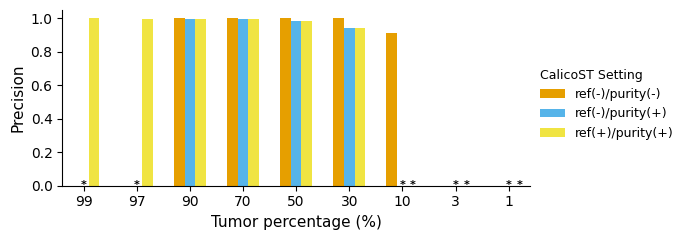

In [24]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (5.5, 2.5), fontsize = 10, total_bar_width = 0.6)
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.wide_version.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

### Plot recall

In [25]:
metric = 'recall'
metric_label = 'Recall'
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,recall,run_id
0,ref(-)/purity(-),0.000000,99
1,ref(+)/purity(+),0.998990,99
2,ref(-)/purity(-),0.000000,97
3,ref(+)/purity(+),1.000000,97
4,ref(-)/purity(-),0.971461,90


/tmp/pbs.1790203.xomics/ipykernel_54619/1775419453.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


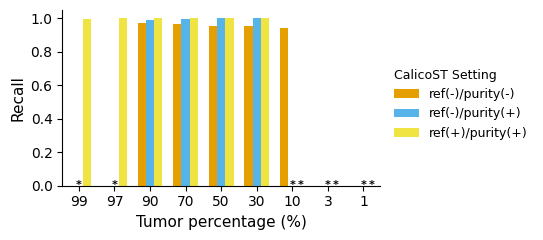

In [26]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (4, 2.5), fontsize = 10)
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

/tmp/pbs.1790203.xomics/ipykernel_54619/1775419453.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


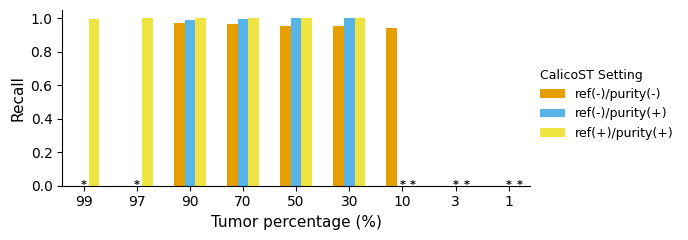

In [27]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (5.5, 2.5), fontsize = 10, total_bar_width = 0.6)
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.wide_version.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

### Plot ARI

In [28]:
metric = 'ARI'
metric_label = 'ARI'    # Adjusted Rand Index
df = dat[['tool', metric, 'run_id']].copy()
df.head()

metric,tool,ARI,run_id
0,ref(-)/purity(-),0.000000,99
1,ref(+)/purity(+),0.950904,99
2,ref(-)/purity(-),0.000000,97
3,ref(+)/purity(+),0.962439,97
4,ref(-)/purity(-),0.845480,90


In [29]:
df['ARI'].min()

0.0

/tmp/pbs.1790203.xomics/ipykernel_54619/1775419453.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


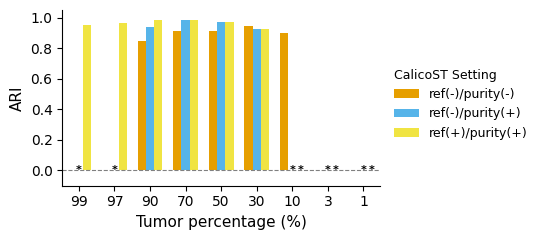

In [30]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (4, 2.5), fontsize = 10, ymin = -0.1)
plt.axhline(0, color = 'grey', linewidth = 0.8, linestyle = '--')
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

/tmp/pbs.1790203.xomics/ipykernel_54619/1775419453.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


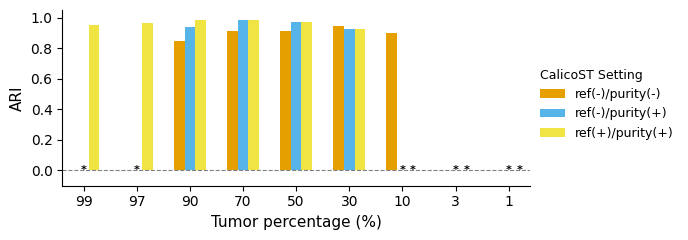

In [31]:
fig, ax = plot_metrics(df, metric = metric, metric_label = metric_label, figsize = (5.5, 2.5), fontsize = 10, total_bar_width = 0.6, ymin = -0.1)
plt.axhline(0, color = 'grey', linewidth = 0.8, linestyle = '--')
fn = os.path.join(out_dir, 'tumor_identification.%s.%s.wide_version.png' % (with_ref, metric))
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')